In [1]:
import numpy as np
from filterpy.kalman import UnscentedKalmanFilter, MerweScaledSigmaPoints
from model.Observer import observer
from scipy.integrate import BDF, RK45, RK23, solve_ivp
from scipy.optimize import root
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Experiment data
folder_path = "./data"
no_experiment = 1
data = pd.read_csv(folder_path+"/test0423"+".csv",sep=";")
data["I actual"] = data["I actual"].str.replace("A","",regex=False).str.replace(",",".",regex=False).astype(float)
data["U actual"] = data["U actual"].str.replace("V","",regex=False).str.replace(",",".",regex=False).astype(float)
data = data[["U actual", "I actual"]]
data["I actual"] = data["I actual"].round(1)
u_expdata = data.iloc[8000:8100,0].to_numpy()
i_expdata = data.iloc[8000:8100,1].to_numpy()
u_expdata = np.tile(u_expdata,10)
i_expdata = np.tile(i_expdata,10)

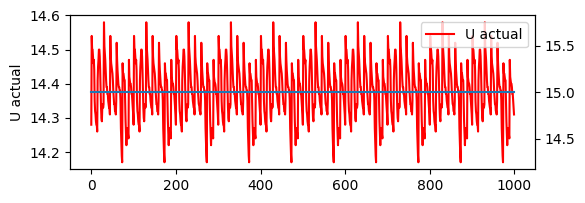

In [3]:
fig,ax = plt.subplots(figsize=(6,2))
ax.plot(u_expdata,label="U actual",color="r")
ax.set_ylabel("U actual")
ax.twinx().plot(i_expdata)
ax.legend()

In [4]:
obs = observer()

In [5]:
# Assumptions
obs.Tfc = 323.15
obs.Pc_des = 1.0e5
obs.Phi_a_des = 0
obs.Phi_c_des = 1
obs.Tfc = 323.15
obs.Sc = 2
obs.dt = 1e-1
obs.t = 0

In [6]:
def iload_square(t, param):
    t_stop = 7200
    k = 20 / t_stop
    iload_rise =  np.tanh(k * (t - t_stop / 4)) + 1
    iload_drop =  np.tanh(-k * (t - t_stop * 3 / 4)) + 1
    return (iload_rise*1/4 + iload_drop*1/4)*0.75e4

def iload_rise(t, param):
    
    cycle_seconds = 3600
    k = 20 / cycle_seconds
    t_cycle = t//cycle_seconds
    
    return (np.tanh(k*(t - t_cycle*cycle_seconds)) + t_cycle)+10

def iload_const(t, param):
    return 10

def implicit_eq(x):
    return np.array(x) - np.array(obs.state) - obs.dt * np.array(obs.dxdt(obs.t, x))

In [7]:
def state_transition(x, dt): 
    obs.t += dt
    sol = root(implicit_eq,x,tol=1e-6)
    return sol.x

def observation_transition(x): 
    return np.array([obs.getUcell(x[3],x[2],x[1],x[9]), obs.Wcp_des])

In [8]:
# Unscented kalman filter
sigmas = MerweScaledSigmaPoints(n=13, alpha=1e-3, beta=1, kappa=0)
filter = UnscentedKalmanFilter(dim_x=13, dim_z=2, fx=state_transition, hx=observation_transition,dt=1e-2,points=sigmas)
# ["lambda_acl","lambda_mem","lambda_ccl", "s_ccl", "C_v_ccl", "s_cgdl", "C_v_cgdl", "C_v_cgc", "C_O2_ccl","C_O2_cgdl","C_O2_cgc","C_N2","Wcp"]
filter.x = [4, 4.5, 5, 0.2, 6, 0.1, 5, 4, 4, 6, 8, 25, obs.Wcp_des]
obs.state = filter.x
filter.R = np.diag([0.6,0.01])
filter.Q = np.diag([0.1, 0.1, 0.1, 0.01, 0.1, 0.01, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0])

In [9]:
x_pred = []
iload_hist = []
ucell_hist = []
error_y_hist = []
for t_snapshot in range(len(u_expdata)):
    
    obs.i_fc = i_expdata[t_snapshot]/25*1e4
    filter.predict()
    filter.update(u_expdata[t_snapshot])
    obs.state = filter.x
    ucell_hist.append(filter.y)
    x_pred.append(filter.x)
    iload_hist.append(obs.i_fc)
    error_y_hist.append(filter.y-filter.z)


In [10]:
t = range(t_snapshot+1)
x_hist = np.array(x_pred)

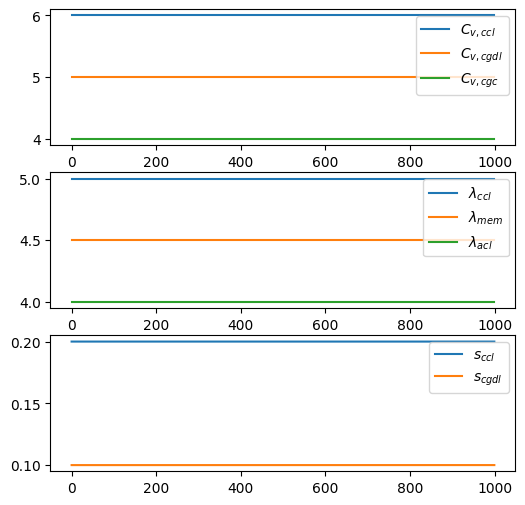

In [11]:
fig, ax = plt.subplots(3,1, figsize = (6,6))
ax[0].plot(t,np.array(x_hist)[:,4], label = r"$C_{v,ccl}$")
ax[0].plot(t,np.array(x_hist)[:,6], label = r"$C_{v,cgdl}$")
ax[0].plot(t,np.array(x_hist)[:,7], label = r"$C_{v,cgc}$")
ax[0].legend()
#ax[0].twinx().plot(t, iload_hist,"--",color = '#000000')
ax[1].plot(t,np.array(x_hist)[:,2], label = r"$\lambda_{ccl}$")
ax[1].plot(t,np.array(x_hist)[:,1], label = r"$\lambda_{mem}$")
ax[1].plot(t,np.array(x_hist)[:,0], label = r"$\lambda_{acl}$")
ax[1].legend()
ax[2].plot(t,np.array(x_hist)[:,3], label = r"$s_{ccl}$")
ax[2].plot(t,np.array(x_hist)[:,5], label = r"$s_{cgdl}$")
ax[2].legend()

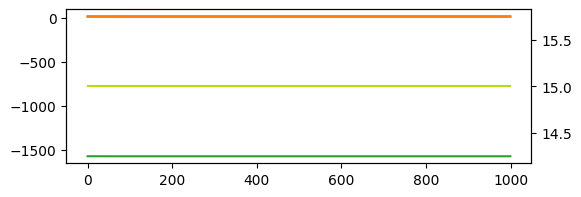

In [12]:
fig,ax = plt.subplots(figsize=(6,2))
ax.plot(u_expdata)
ax.plot(ucell_hist)
ax.twinx().plot(i_expdata, color = "#B0DF0B")

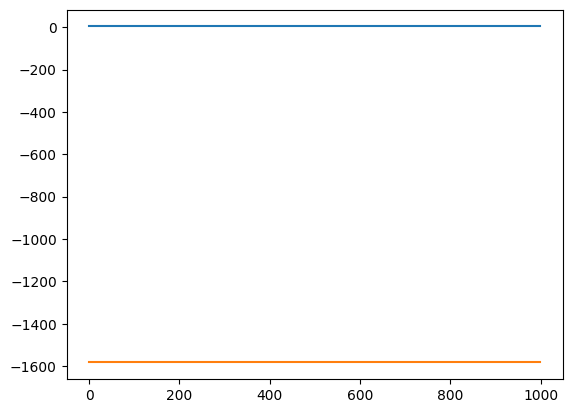

In [13]:
plt.plot(error_y_hist)